# Set Up

In [1]:
# Import necessary packages
import pandas as pd
from nilearn import surface
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from scipy.stats import pearsonr

from utils import calculate_label_area, annotate_regression_corr

In [ ]:
#flag to save files
save_CSVs=False

#define label, and hemi lists
ROIs = ['VWFA1','VWFA2']
hemis = ['LH']

# define paths
project_dir = os.chdir('..')
fig_dir = f'{project_dir}figures/'
data_dir = f'{project_dir}data/'
fs_dir = f'{data_dir}freesurfer/'

#define sub list
groups = pd.read_csv(f'{data_dir}DFs/groups.csv')
subs = list(groups['sub'])


# Extract ROI Size Data

In [15]:
# set up empty list to collect data
data = []

# loop through subs and hemis
for sub in subs:
    for hemi in hemis:
        
        # Load the pial surface mesh
        surf_mesh = f'{fs_dir}{sub}/surf/lh.inflated'
        coords, faces = surface.load_surf_mesh(surf_mesh)

        # loop through ROIs
        for roi in ROIs:

            # calculate size of roi
            label_path = f'{fs_dir}{sub}/label/{sub}_T-v-ALL_{roi}_{hemi}.label'
            if os.path.exists(label_path):
                my_label = surface.load_surf_data(label_path)
                size = calculate_label_area(coords, faces, my_label)

            # if sub doesn't have roi - specify size 0
            else:
                size = 0
                
            #gather the data
            data.append({
                    'sub': sub,
                    'hemi': hemi,
                    'roi': roi, 
                    'size': size
                        })
    print(sub) #to show progress
                
# Create DataFrame
df = pd.DataFrame(data)   

# save df as csv
if save_CSVs:
    
    #merge df with sub group data
    df = pd.merge(df,groups,how='left',on='sub')
   
    #merge df with reading score data
    scores = pd.read_csv(f'{data_dir}DFs/wj_scores.csv')
    df = pd.merge(df,scores,how='left',on='sub')
    df.to_csv(f'{data_dir}DFs/roi_size.csv',index=False)
    

sub-1
sub-2
sub-3
sub-4
sub-5
sub-6
sub-7
sub-9
sub-10
sub-11
sub-12
sub-13
sub-14
sub-15
sub-16
sub-17
sub-18
sub-19
sub-20
sub-21
sub-22
sub-23
sub-24
sub-25
sub-26
sub-27
sub-29
sub-30
sub-32
sub-33
sub-34
sub-35
sub-36
sub-37
sub-38
sub-39
sub-40
sub-41
sub-42
sub-43
sub-44
sub-45
sub-46
sub-47
sub-48
sub-49
sub-50
sub-51
sub-52
sub-53
sub-54
sub-55
sub-56
sub-57
sub-58
sub-59
sub-60
sub-61
sub-62
sub-63
sub-64
sub-65
sub-67
sub-68
sub-69
sub-71
sub-72
sub-73
sub-74
sub-75
sub-76
sub-77
sub-78
sub-79
sub-80
sub-81
sub-83
sub-84
sub-85
sub-86
sub-87
sub-88
sub-89
sub-90


# Plot & Analyze

VWFA1
dys: 27.213, 48.261
typ: 89.580, 95.042
dys/typ prop: 0.30378716721740406
t(82.00)=-3.916 (p=0.0002; CI=(-94.05, -30.69))
cohen d: -0.9458153046210089
VWFA2
dys: 29.312, 42.035
typ: 148.640, 152.810
dys/typ prop: 0.19719853531267686
t(82.00)=-5.480 (p=0.0000; CI=(-162.64, -76.01))
cohen d: -1.3236471399116512


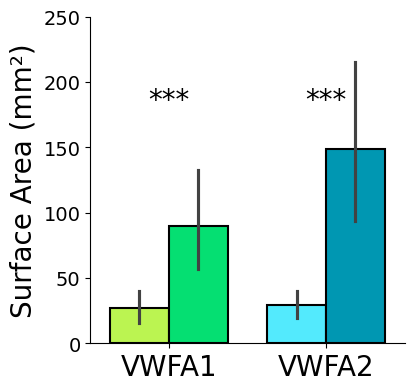

In [21]:
# Set to True if you want to save the figure
save_fig = False

# Define color palettes for each ROI
vwfa1_palette = {'dys': '#BBF451', 'typ': '#05DF72'}
vwfa2_palette = {'dys': '#53EAFD', 'typ':'#0097b2'}

#read in data
df_size = pd.read_csv(f'{data_dir}DFs/roi_size.csv')

# Calculate p-values for significance using t-tests
p_values = []
t_values=[]
DOFs=[]
CIs=[]
avg_sizes=[]

for roi in ROIs:
    # Get sizes for each ROI and group
    roi_df = df_size.query('roi==@roi')
    dys_size = roi_df.query('dys_group=="dys"')
    typ_size = roi_df.query('dys_group=="typ"')

    # run test
    results = ttest_ind(dys_size["size"], typ_size["size"])

    # grab results
    t = results.statistic
    p = results.pvalue
    DOF = results.df
    CI = results.confidence_interval()
    
    #append results
    t_values.append(t)
    p_values.append(p)
    DOFs.append(DOF)
    CIs.append(CI)

    #print results
    print(roi)
    print(f'dys: {np.mean(dys_size["size"]):.3f}, {np.std(dys_size["size"]):.3f}')
    print(f'typ: {np.mean(typ_size["size"]):.3f}, {np.std(typ_size["size"]):.3f}')
    print(f'dys/typ prop: {np.mean(dys_size["size"])/np.mean(typ_size["size"])}')
    print(f't({DOF:.2f})={t:.3f} (p={p:.4f}; CI=({CI.low:.2f}, {CI.high:.2f}))')
    

    # calcualte Cohen's D
    group1 = np.array(dys_size['size'])
    group2 = np.array(typ_size['size'])
    
    # Calculate means
    mean1, mean2 = np.mean(group1), np.mean(group2)
    
    # Calculate variances
    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    
    # Calculate pooled standard deviation
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    
    print(f'cohen d: {(mean1 - mean2) / pooled_std}')
        
    

# Plot the data
g = sns.catplot(x='roi', y='size', hue='dys_group', hue_order=['dys', 'typ'],
                data=df_size, kind='bar', 
                height=4, aspect=1, width=0.75, legend=False)
g.set_axis_labels("", "Surface Area (mm\u00b2)", size=20)
g.set_xticklabels(size=20)
g.set_yticklabels(size=14)

# Manually color the bars based on ROI
ax = g.axes.flat[0]
for i, bar in enumerate(ax.patches):
    # Determine which ROI and group this bar belongs to
    roi_idx = i % 2  # 0 for VWFA1, 1 for VWFA2
    group_idx = i // 2  # 0 for dys, 1 for typ
    
    roi = ROIs[roi_idx]
    group = ['dys', 'typ'][group_idx]
    
    # Set the color
    if roi == 'VWFA1':
        bar.set_facecolor(vwfa1_palette[group])
    elif roi == 'VWFA2':
        bar.set_facecolor(vwfa2_palette[group])
    
    # Add border
    bar.set_edgecolor('black')  
    bar.set_linewidth(1.5)

# Add significance indicators
for i, p in enumerate(p_values):
    significance = ''
    if pd.notna(p):
        if p < 0.001:
            significance = '***'
        elif p < 0.01:
            significance = '**'
        elif p < 0.05:
            significance = '*'
        elif p >= 0.05:
            significance = ''
    if significance:
        # Position the text above the highest box for the given ROI
        y_max = 175
        if np.isfinite(y_max):  
            ax = g.axes.flat[0]
            ax.text(i, y_max + 0.1, significance, ha='center', va='bottom', fontsize=20, color='black')

# Save the figure
if save_fig:
    plt.savefig(f'{fig_dir}sizes_bar.png', bbox_inches="tight", dpi=400)

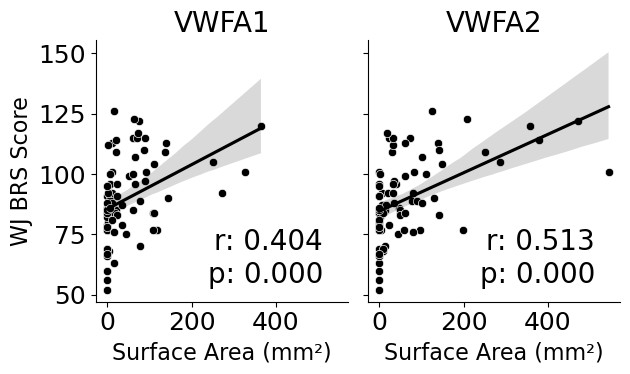

In [26]:
save_fig = False

# Define assessment titles
titles = {
    'wj_brs': 'WJ BRS'
}

#define variables
assessments = ['wj_brs']

# Pivot long and create a new column for the assessment
data_long = pd.melt(df_size, id_vars=['sub', 'roi', 'dys_group','hemi','size'], value_vars=assessments, 
                    var_name='assessment', value_name='score')

# Create a FacetGrid
g = sns.FacetGrid(data_long, row='assessment', col='roi', 
                  height=4, 
                  aspect=.8)

# Map the scatterplot and regplot onto the FacetGrid
g.map(sns.scatterplot, 'size', 'score', color='black')
g.map(sns.regplot, 'size', 'score', scatter=False, color='black')

# Apply the annotation function to each subplot
g.map_dataframe(annotate_regression_corr,x_param='size',y_param='score')

# Set uniform x and y-axis labels
g.set_axis_labels('Surface Area (mm\u00b2)', 'WJ BRS Score', size=16)

# Iterate through the axes and set the tick label font size
for ax in g.axes.flat:
    ax.tick_params(axis='both', labelsize=18)

# Set titles and labels for each subplot
for i, roi in enumerate(ROIs):
    for j, assessment in enumerate(assessments):
        ax = g.axes[j, i]
        ax.set_title(f'{roi}', size=20)

# Adjust layout to ensure labels are visible
plt.tight_layout(rect=[0, 0, 1, 0.96])

if save_fig:
    g.savefig(f'{fig_dir}sizeXscores.png', bbox_inches="tight", dpi=400)

plt.show()
